<p align="center">
  <a href="https://imc.uc.cl" target="_blank">
    <img src="attachment:image.png" alt="IMC" width="220">
  </a>
</p>

# IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Profesor:** Rodrigo A. Carrasco <br>
---


## Tarea 04 – Aprendizaje automático

- **Fecha de Entrega:** 13 de noviembre de 2025, a las 23:59.
- **Fecha de publicación**: 30 de octubre de 2025.
- **Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 04 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tara.

- Deben hacer sus consultas y comentarios sobre la Tarea a traves del canal de Tareas en eo del curso en Canvas.os.
cteriza.

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

### 1.2 Pregunta de ciencia de datos

Esta tarea tendrá como objetivo crear un predictor que determine el éxito o fracaso de una expedición a distintas montañas del Himalayas según datos del montañista y de la expedición. Vamos a responder a la pregunta de qué tan bien pueden atributos como año, estación, montaña, edad del montañista, entre otros, predecir el éxito o fracaso de una expedición.

### 1.3 Recomendaciones
- Utiliza las librerías sugeridas en el notebook o justifica brevemente si incorporas otras.
- Revisa que todas las celdas se ejecuten en orden, desde el inicio, sin errores.
- Comenta tu código para explicar qué hace cada sección relevante.
- Asegúrate de que las visualizaciones sean fáciles de interpretar y tengan títulos y etiquetas adecuados.

## 2. Datos

[The Himalayan Database](https://www.himalayandatabase.com/) consiste en una colección de registros de expediciones en la cordillera del Himalaya. Esta contiene información detallada de las cimas más altas del mundo, junto con miles de expediciones realizadas desde 1905 hasta 2024 e información de cada uno de los/las montañistas que han participado en ellas. (El dataset que utilizaremos fue extraído desde: https://mavenanalytics.io/data-playground/himalayan-expeditions)

Descargue el archivo `Himalayan+Expeditions.zip` disponible en el repositorio del curso. Como puede ver, esta información está separada en varios archivos `.csv`. Deberá utilizar las herramientas aprendidas durante el curso para juntar esta información, procesarla y crear un predictor que determine el éxito de una subida.

**Recomendación**: Puede revisar el archivo `himalayan_data_dictionary.csv` para saber el significado de cada una de las columnas de la base de datos.

### 2.1 Librerías

Para esta tarea puede utilizar cualquiera de las librerías previamente utilizadas en el curso. Puede agregar otras si lo estima conveniente para el desarrollo de la Tarea.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# ...agreuge otras librerías si lo considera relevante

# Agrego todas las librerias que se usan para los modelos de prediccion que se usan en esta tarea como en las clases y ayudantias
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

## 3. Carga y limpieza (1 punto)

### 3.1 DataFrame unificado (0.2 pts)

Inspeccione los atributos de cada dataset y extraiga la siguiente información de ellos:

1. Información de las montañas:
    * ID de la cima (`peakid`)
    * Nombre común de la montaña (`pkname`)
    * Altura (m) (`heightm`)
    * Cantidad de expediciones exitosas (`success_exp`)
    * Cantidad de expediciones fallidas (`failed_exp`)

2. Información de las expediciones:
    * ID de la expedición (`expid`)
    * Año (`year`)
    * Estación del año (`season`)

3. Información de los montañistas:
    * ID del miembro (`memid`)
    * Sexo (`sex`)
    * Año de nacimiento (`yob`)
    * Nacionalidad (`citizen`)
    * Completó la expedición exitosamente (`msuccess`)

Genere un único DataFrame con todos estos atributos, donde cada fila represente el ascenso de un/a montañista en una expedición. (Ojo que esto no necesariamente significa que cada fila será una persona diferente: si una persona escaló dos cumbres distintas en dos expediciones, esta debería aparecer en su DataFrame como dos filas separadas.)


In [197]:
# respuestas
df_exped = pd.read_csv("exped.csv")

# Por alguna razon el csv no esta en el predeterminado utf-8, por lotanto lo abrimos con latin1
df_refer = pd.read_csv("refer.csv", encoding="latin1")

df_peaks = pd.read_csv("peaks.csv")

df_peaks_with_exp = pd.read_csv("peaks_with_exp.csv")

df_members = pd.read_csv("members.csv")


C:\Users\crist\AppData\Local\Temp\ipykernel_21384\2760736629.py:2: DtypeWarning: Columns (8,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df_exped = pd.read_csv("exped.csv")
C:\Users\crist\AppData\Local\Temp\ipykernel_21384\2760736629.py:11: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  df_members = pd.read_csv("members.csv")


In [198]:
df_exped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11425 entries, 0 to 11424
Data columns (total 65 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   expid       11425 non-null  object 
 1   peakid      11425 non-null  object 
 2   year        11425 non-null  int64  
 3   season      11425 non-null  object 
 4   host        11425 non-null  object 
 5   route1      11275 non-null  object 
 6   route2      360 non-null    object 
 7   route3      30 non-null     object 
 8   route4      5 non-null      object 
 9   nation      11425 non-null  object 
 10  leaders     11401 non-null  object 
 11  sponsor     10609 non-null  object 
 12  success1    11425 non-null  bool   
 13  success2    11425 non-null  bool   
 14  success3    11425 non-null  bool   
 15  success4    11425 non-null  bool   
 16  ascent1     2778 non-null   object 
 17  ascent2     101 non-null    object 
 18  ascent3     11 non-null     object 
 19  ascent4     4 non-null   

In [199]:
df_refer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15586 entries, 0 to 15585
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   expid       15586 non-null  object 
 1   refid       15586 non-null  int64  
 2   ryear       15586 non-null  int64  
 3   rtype       15583 non-null  object 
 4   rjrnl       7218 non-null   object 
 5   rauthor     5283 non-null   object 
 6   rtitle      10065 non-null  object 
 7   rpublisher  1130 non-null   object 
 8   rpubdate    8306 non-null   float64
 9   rlanguage   2352 non-null   object 
 10  rcitation   7234 non-null   object 
 11  ryak94      631 non-null    object 
dtypes: float64(1), int64(2), object(9)
memory usage: 1.4+ MB


In [200]:
df_peaks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   peakid      480 non-null    object 
 1   pkname      480 non-null    object 
 2   pkname2     257 non-null    object 
 3   location    479 non-null    object 
 4   heightm     480 non-null    int64  
 5   heightf     480 non-null    int64  
 6   himal       480 non-null    object 
 7   region      480 non-null    object 
 8   open        480 non-null    bool   
 9   unlisted    480 non-null    bool   
 10  trekking    480 non-null    bool   
 11  trekyear    29 non-null     float64
 12  restrict    275 non-null    object 
 13  phost       480 non-null    object 
 14  pstatus     480 non-null    object 
 15  pyear       362 non-null    float64
 16  pseason     363 non-null    object 
 17  pmonth      357 non-null    object 
 18  pday        340 non-null    float64
 19  pexpid      360 non-null    o

In [201]:
df_peaks_with_exp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 25 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   peakid       480 non-null    object 
 1   pkname       480 non-null    object 
 2   pkname2      257 non-null    object 
 3   location     479 non-null    object 
 4   heightm      480 non-null    int64  
 5   heightf      480 non-null    int64  
 6   himal        480 non-null    object 
 7   region       480 non-null    object 
 8   open         480 non-null    bool   
 9   unlisted     480 non-null    bool   
 10  trekking     480 non-null    bool   
 11  trekyear     29 non-null     float64
 12  restrict     275 non-null    object 
 13  phost        480 non-null    object 
 14  pstatus      480 non-null    object 
 15  pyear        362 non-null    float64
 16  pseason      363 non-null    object 
 17  pmonth       357 non-null    object 
 18  pday         340 non-null    float64
 19  pexpid  

In [202]:
df_members.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89000 entries, 0 to 88999
Data columns (total 61 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   expid       89000 non-null  object 
 1   membid      89000 non-null  int64  
 2   peakid      89000 non-null  object 
 3   myear       89000 non-null  int64  
 4   mseason     89000 non-null  object 
 5   fname       88897 non-null  object 
 6   lname       87876 non-null  object 
 7   sex         89000 non-null  object 
 8   yob         83592 non-null  float64
 9   citizen     88993 non-null  object 
 10  status      89000 non-null  object 
 11  residence   80170 non-null  object 
 12  occupation  58261 non-null  object 
 13  leader      89000 non-null  bool   
 14  deputy      89000 non-null  bool   
 15  bconly      89000 non-null  bool   
 16  nottobc     89000 non-null  bool   
 17  support     89000 non-null  bool   
 18  disabled    89000 non-null  bool   
 19  hired       89000 non-nul

In [203]:
# Información de las montanas
df_info_montanas = df_peaks_with_exp[['peakid', 'pkname', 'heightm', 'success_exp', 'failed_exp']]
df_info_montanas.head()

,peakid,pkname,heightm,success_exp,failed_exp
0,ACHN,Aichyn,6055,2,1
1,AMAD,Ama Dablam,6814,1123,453
2,AMOT,Amotsang,6393,1,2
3,AMPG,Amphu Gyabjen,5630,3,1
4,AMPH,Amphu I,6740,1,1


In [204]:
df_info_montanas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   peakid       480 non-null    object
 1   pkname       480 non-null    object
 2   heightm      480 non-null    int64 
 3   success_exp  480 non-null    int64 
 4   failed_exp   480 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 18.9+ KB


In [205]:
# Informacion de las expediciones (se le suma peakid para unir con montanas)
df_info_exp = df_exped[['expid', 'year', 'season', 'peakid']]
df_info_exp.head()

,expid,year,season,peakid
0,ANN260101,1960,Spring,ANN2
1,ANN269301,1969,Autumn,ANN2
2,ANN273101,1973,Spring,ANN2
3,ANN278301,1978,Autumn,ANN2
4,ANN279301,1979,Autumn,ANN2


In [206]:
df_info_exp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11425 entries, 0 to 11424
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   expid   11425 non-null  object
 1   year    11425 non-null  int64 
 2   season  11425 non-null  object
 3   peakid  11425 non-null  object
dtypes: int64(1), object(3)
memory usage: 357.2+ KB


In [207]:
# Como season esta como objeto y solo hay 4 opciones, la transformamos a category
df_info_exp['season'] = df_info_exp['season'].astype('category')
df_info_exp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11425 entries, 0 to 11424
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   expid   11425 non-null  object  
 1   year    11425 non-null  int64   
 2   season  11425 non-null  category
 3   peakid  11425 non-null  object  
dtypes: category(1), int64(1), object(2)
memory usage: 279.3+ KB


C:\Users\crist\AppData\Local\Temp\ipykernel_21384\3120423010.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_info_exp['season'] = df_info_exp['season'].astype('category')


In [208]:
# Informacion monatnistas (se le suma expid para unir con expediciones)
df_info_montanistas = df_members[['membid', 'sex', 'yob', 'citizen', 'msuccess', 'expid']]
df_info_montanistas.head()

,membid,sex,yob,citizen,msuccess,expid
0,2,M,1972.0,Australia,False,AMAD01101
1,1,M,1968.0,Australia,False,AMAD01101
2,3,M,1960.0,Australia,False,AMAD01101
3,4,M,1966.0,Australia,False,AMAD01101
4,5,F,1970.0,Australia,False,AMAD01101


In [209]:
df_info_montanistas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89000 entries, 0 to 88999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   membid    89000 non-null  int64  
 1   sex       89000 non-null  object 
 2   yob       83592 non-null  float64
 3   citizen   88993 non-null  object 
 4   msuccess  89000 non-null  bool   
 5   expid     89000 non-null  object 
dtypes: bool(1), float64(1), int64(1), object(3)
memory usage: 3.5+ MB


In [210]:
df_info_montanistas['sex'] = df_info_montanistas['sex'].astype('category')
# La columna de sexo se cambio a category por tener dos opciones
df_info_montanistas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89000 entries, 0 to 88999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   membid    89000 non-null  int64   
 1   sex       89000 non-null  category
 2   yob       83592 non-null  float64 
 3   citizen   88993 non-null  object  
 4   msuccess  89000 non-null  bool    
 5   expid     89000 non-null  object  
dtypes: bool(1), category(1), float64(1), int64(1), object(2)
memory usage: 2.9+ MB


C:\Users\crist\AppData\Local\Temp\ipykernel_21384\3395039316.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_info_montanistas['sex'] = df_info_montanistas['sex'].astype('category')


In [211]:
df_unido = pd.merge(df_info_exp, df_info_montanas, on='peakid', how='outer')
df_unido = pd.merge(df_unido, df_info_montanistas, on='expid', how='outer')
df_unido.head()

,expid,year,season,peakid,pkname,heightm,success_exp,failed_exp,membid,sex,yob,citizen,msuccess
0,ACHN15301,2015.0,Autumn,ACHN,Aichyn,6055,2,1,1.0,M,1992.0,Japan,True
1,ACHN15301,2015.0,Autumn,ACHN,Aichyn,6055,2,1,2.0,F,1992.0,Japan,True
2,ACHN15301,2015.0,Autumn,ACHN,Aichyn,6055,2,1,4.0,M,1990.0,Japan,True
3,ACHN15301,2015.0,Autumn,ACHN,Aichyn,6055,2,1,5.0,M,1993.0,Japan,True
4,ACHN15301,2015.0,Autumn,ACHN,Aichyn,6055,2,1,3.0,M,1995.0,Japan,True


In [212]:
df_unido.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89168 entries, 0 to 89167
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   expid        89104 non-null  object  
 1   year         89104 non-null  float64 
 2   season       89104 non-null  category
 3   peakid       89168 non-null  object  
 4   pkname       89168 non-null  object  
 5   heightm      89168 non-null  int64   
 6   success_exp  89168 non-null  int64   
 7   failed_exp   89168 non-null  int64   
 8   membid       89089 non-null  float64 
 9   sex          89089 non-null  category
 10  yob          83665 non-null  float64 
 11  citizen      89082 non-null  object  
 12  msuccess     89089 non-null  object  
dtypes: category(2), float64(3), int64(3), object(5)
memory usage: 7.7+ MB


### 3.2 Limpieza y transformación (0.2 pts)

Inspeccione y procese su DataFrame para generar uno nuevo llamado `clean_df`. En esta sección usted debe decidir si es necesario:

* Limpiar valores nulos, duplicados o inválidos.
* Imputar valores.
* Transformar tipos de columnas.

Justifique su procesamiento.

In [213]:
# respuestas
filas_nulas = df_unido[df_unido['expid'].isnull()]
filas_nulas

,expid,year,season,peakid,pkname,heightm,success_exp,failed_exp,membid,sex,yob,citizen,msuccess
89104,NaN,NaN,NaN,APIW,Api West,7076,0,0,NaN,NaN,NaN,NaN,NaN
89105,NaN,NaN,NaN,ASAJ,Asajya Tuppa,6265,0,0,NaN,NaN,NaN,NaN,NaN
89106,NaN,NaN,NaN,CHAB,Chabuk,6792,0,0,NaN,NaN,NaN,NaN,NaN
89107,NaN,NaN,NaN,CHMR,Chamar,7161,0,0,NaN,NaN,NaN,NaN,NaN
89108,NaN,NaN,NaN,CHNG,Changdi,6623,0,0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
89163,NaN,NaN,NaN,YANG,Yangri,6535,0,0,NaN,NaN,NaN,NaN,NaN
89164,NaN,NaN,NaN,YARW,Yarwa,6644,0,0,NaN,NaN,NaN,NaN,NaN
89165,NaN,NaN,NaN,YNGS,Yangra Kangri South,6863,0,0,NaN,NaN,NaN,NaN,NaN
89166,NaN,NaN,NaN,YOKO,Yokopahar,6423,0,0,NaN,NaN,NaN,NaN,NaN


In [214]:
# Como lo que queremos analizar son las expediciones, los valores nulos en expid, son de aquellas montanas sin expediciones, por lo tanto no nos sirve de nada
clean_df = df_unido.copy()
clean_df = clean_df.dropna(subset='expid')
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89104 entries, 0 to 89103
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   expid        89104 non-null  object  
 1   year         89104 non-null  float64 
 2   season       89104 non-null  category
 3   peakid       89104 non-null  object  
 4   pkname       89104 non-null  object  
 5   heightm      89104 non-null  int64   
 6   success_exp  89104 non-null  int64   
 7   failed_exp   89104 non-null  int64   
 8   membid       89089 non-null  float64 
 9   sex          89089 non-null  category
 10  yob          83665 non-null  float64 
 11  citizen      89082 non-null  object  
 12  msuccess     89089 non-null  object  
dtypes: category(2), float64(3), int64(3), object(5)
memory usage: 8.3+ MB


In [215]:
filas_nulas = clean_df[clean_df['membid'].isnull()]
filas_nulas

,expid,year,season,peakid,pkname,heightm,success_exp,failed_exp,membid,sex,yob,citizen,msuccess
18135,CHEO87301,1987.0,Autumn,CHEO,Cheo Himal,6820,1,2,NaN,NaN,NaN,NaN,NaN
29625,DHA149001,1949.0,Unknown,DHA1,Dhaulagiri I,8167,183,241,NaN,NaN,NaN,NaN,NaN
47307,EVER19185,2019.0,Spring,EVER,Everest,8849,1495,852,NaN,NaN,NaN,NaN,NaN
49912,EVER23150,2023.0,Spring,EVER,Everest,8849,1495,852,NaN,NaN,NaN,NaN,NaN
51278,EVER65102,1965.0,Spring,EVER,Everest,8849,1495,852,NaN,NaN,NaN,NaN,NaN
51284,EVER68101,1968.0,Spring,EVER,Everest,8849,1495,852,NaN,NaN,NaN,NaN,NaN
51910,EVER79102,1979.0,Spring,EVER,Everest,8849,1495,852,NaN,NaN,NaN,NaN,NaN
58413,GAUR73301,1973.0,Autumn,GAUR,Gaurishankar,7135,6,27,NaN,NaN,NaN,NaN,NaN
64895,KGUR65101,1965.0,Spring,KGUR,Kang Guru,6981,18,13,NaN,NaN,NaN,NaN,NaN
72507,MAKA34101,1934.0,Spring,MAKA,Makalu,8485,171,212,NaN,NaN,NaN,NaN,NaN


In [216]:
#Tampoco nos sirve expediciones que no sabemos quienes la hicieron
clean_df = clean_df.dropna(subset='membid')
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89089 entries, 0 to 89103
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   expid        89089 non-null  object  
 1   year         89089 non-null  float64 
 2   season       89089 non-null  category
 3   peakid       89089 non-null  object  
 4   pkname       89089 non-null  object  
 5   heightm      89089 non-null  int64   
 6   success_exp  89089 non-null  int64   
 7   failed_exp   89089 non-null  int64   
 8   membid       89089 non-null  float64 
 9   sex          89089 non-null  category
 10  yob          83665 non-null  float64 
 11  citizen      89082 non-null  object  
 12  msuccess     89089 non-null  object  
dtypes: category(2), float64(3), int64(3), object(5)
memory usage: 8.3+ MB


In [217]:
filas_nulas = clean_df[clean_df['citizen'].isnull()]
filas_nulas

,expid,year,season,peakid,pkname,heightm,success_exp,failed_exp,membid,sex,yob,citizen,msuccess
65402,KOTA51301,1951.0,Autumn,KOTA,Kotang,6148,9,4,3.0,M,NaN,NaN,False
65405,KOTA53101,1953.0,Spring,KOTA,Kotang,6148,9,4,3.0,M,NaN,NaN,False
65406,KOTA53101,1953.0,Spring,KOTA,Kotang,6148,9,4,4.0,M,NaN,NaN,False
65414,KOTA62101,1962.0,Spring,KOTA,Kotang,6148,9,4,4.0,M,NaN,NaN,False
65415,KOTA62101,1962.0,Spring,KOTA,Kotang,6148,9,4,5.0,M,NaN,NaN,False
65493,KOTA93302,1993.0,Autumn,KOTA,Kotang,6148,9,4,10.0,M,NaN,NaN,False
65494,KOTA93302,1993.0,Autumn,KOTA,Kotang,6148,9,4,11.0,M,NaN,NaN,False


In [218]:
filas_nulas = clean_df[clean_df['yob'].isnull()]
filas_nulas

,expid,year,season,peakid,pkname,heightm,success_exp,failed_exp,membid,sex,yob,citizen,msuccess
50,AMAD00106,2000.0,Spring,AMAD,Ama Dablam,6814,1123,453,2.0,M,NaN,Nepal,False
51,AMAD00106,2000.0,Spring,AMAD,Ama Dablam,6814,1123,453,3.0,M,NaN,Nepal,False
151,AMAD00314,2000.0,Autumn,AMAD,Ama Dablam,6814,1123,453,14.0,M,NaN,Nepal,True
178,AMAD00318,2000.0,Autumn,AMAD,Ama Dablam,6814,1123,453,12.0,M,NaN,Nepal,True
180,AMAD00318,2000.0,Autumn,AMAD,Ama Dablam,6814,1123,453,11.0,M,NaN,Nepal,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
89011,YALU87301,1987.0,Autumn,YALU,Yalung Kang,8505,12,10,6.0,M,NaN,Nepal,False
89021,YALU88301,1988.0,Autumn,YALU,Yalung Kang,8505,12,10,10.0,M,NaN,Nepal,False
89054,YALU89301,1989.0,Autumn,YALU,Yalung Kang,8505,12,10,9.0,M,NaN,Nepal,True
89055,YALU89301,1989.0,Autumn,YALU,Yalung Kang,8505,12,10,10.0,M,NaN,Nepal,True


In [219]:
# A pesar de que aun quedan datos nulos, estas filas igual contienen informacion que puede ser util, por lo tanto las mantenemos
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89089 entries, 0 to 89103
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   expid        89089 non-null  object  
 1   year         89089 non-null  float64 
 2   season       89089 non-null  category
 3   peakid       89089 non-null  object  
 4   pkname       89089 non-null  object  
 5   heightm      89089 non-null  int64   
 6   success_exp  89089 non-null  int64   
 7   failed_exp   89089 non-null  int64   
 8   membid       89089 non-null  float64 
 9   sex          89089 non-null  category
 10  yob          83665 non-null  float64 
 11  citizen      89082 non-null  object  
 12  msuccess     89089 non-null  object  
dtypes: category(2), float64(3), int64(3), object(5)
memory usage: 8.3+ MB


In [220]:
# Cambiar las columnas de los anos de float a int es lo que mejor se ve, pero como yob contiene nan, que pandas lo considera un float, no se puede cambiar a int, por ende lo dejamos en float, ya que no influye mas que esteticamente, como si influiria en el calculo sacar los nan

clean_df['membid'].unique()
# Por otro lado, membid solo tiene ints, por ende lo transformamos a ints
clean_df['membid'] = clean_df['membid'].astype(int)
clean_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 89089 entries, 0 to 89103
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   expid        89089 non-null  object  
 1   year         89089 non-null  float64 
 2   season       89089 non-null  category
 3   peakid       89089 non-null  object  
 4   pkname       89089 non-null  object  
 5   heightm      89089 non-null  int64   
 6   success_exp  89089 non-null  int64   
 7   failed_exp   89089 non-null  int64   
 8   membid       89089 non-null  int64   
 9   sex          89089 non-null  category
 10  yob          83665 non-null  float64 
 11  citizen      89082 non-null  object  
 12  msuccess     89089 non-null  object  
dtypes: category(2), float64(2), int64(4), object(5)
memory usage: 8.3+ MB


### 3.2 Creación de nuevas columnas (0.6 pts)

Vamos a crear un par de columnas nuevas que nos ayudarán a hacer una análisis exploratorio del dataset.
Utilizando las columnas actuales, genere y agregue las siguientes columnas a su DataFrame:

* `age`: Edad del montañista a la fecha de la expedición.
* `peak_success_p`: Porcentaje de expediciones exitosas de la cima respectiva.

De ser necesario, aplique procesos de limpieza y transformación a estas columnas también (asegúrese de que todos los valores sean coherentes).

In [221]:
clean_df.head()

,expid,year,season,peakid,pkname,heightm,success_exp,failed_exp,membid,sex,yob,citizen,msuccess
0,ACHN15301,2015.0,Autumn,ACHN,Aichyn,6055,2,1,1,M,1992.0,Japan,True
1,ACHN15301,2015.0,Autumn,ACHN,Aichyn,6055,2,1,2,F,1992.0,Japan,True
2,ACHN15301,2015.0,Autumn,ACHN,Aichyn,6055,2,1,4,M,1990.0,Japan,True
3,ACHN15301,2015.0,Autumn,ACHN,Aichyn,6055,2,1,5,M,1993.0,Japan,True
4,ACHN15301,2015.0,Autumn,ACHN,Aichyn,6055,2,1,3,M,1995.0,Japan,True


In [222]:
# respuestas
nuevo_df = clean_df.copy()
nuevo_df['age'] = nuevo_df['year'] - nuevo_df['yob']
nuevo_df.head()

,expid,year,season,peakid,pkname,heightm,success_exp,failed_exp,membid,sex,yob,citizen,msuccess,age
0,ACHN15301,2015.0,Autumn,ACHN,Aichyn,6055,2,1,1,M,1992.0,Japan,True,23.0
1,ACHN15301,2015.0,Autumn,ACHN,Aichyn,6055,2,1,2,F,1992.0,Japan,True,23.0
2,ACHN15301,2015.0,Autumn,ACHN,Aichyn,6055,2,1,4,M,1990.0,Japan,True,25.0
3,ACHN15301,2015.0,Autumn,ACHN,Aichyn,6055,2,1,5,M,1993.0,Japan,True,22.0
4,ACHN15301,2015.0,Autumn,ACHN,Aichyn,6055,2,1,3,M,1995.0,Japan,True,20.0


In [223]:
# Verifica que las filas con yob nan tengan nan en year
filas_yob_nan = nuevo_df[nuevo_df['yob'].isnull()]
filas_yob_nan

,expid,year,season,peakid,pkname,heightm,success_exp,failed_exp,membid,sex,yob,citizen,msuccess,age
50,AMAD00106,2000.0,Spring,AMAD,Ama Dablam,6814,1123,453,2,M,NaN,Nepal,False,NaN
51,AMAD00106,2000.0,Spring,AMAD,Ama Dablam,6814,1123,453,3,M,NaN,Nepal,False,NaN
151,AMAD00314,2000.0,Autumn,AMAD,Ama Dablam,6814,1123,453,14,M,NaN,Nepal,True,NaN
178,AMAD00318,2000.0,Autumn,AMAD,Ama Dablam,6814,1123,453,12,M,NaN,Nepal,True,NaN
180,AMAD00318,2000.0,Autumn,AMAD,Ama Dablam,6814,1123,453,11,M,NaN,Nepal,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89011,YALU87301,1987.0,Autumn,YALU,Yalung Kang,8505,12,10,6,M,NaN,Nepal,False,NaN
89021,YALU88301,1988.0,Autumn,YALU,Yalung Kang,8505,12,10,10,M,NaN,Nepal,False,NaN
89054,YALU89301,1989.0,Autumn,YALU,Yalung Kang,8505,12,10,9,M,NaN,Nepal,True,NaN
89055,YALU89301,1989.0,Autumn,YALU,Yalung Kang,8505,12,10,10,M,NaN,Nepal,True,NaN


In [224]:
nuevo_df['age'].unique()

array([ 23.,  25.,  22.,  20.,  58.,  54.,  57.,  66.,  40.,  60.,  41.,
        50.,  28.,  29.,  59.,  32.,  45.,  35.,  68.,  33.,  34.,  31.,
        26.,  39.,  37.,  51.,  56.,  42.,  nan,  44.,  30.,  53.,  49.,
        47.,  38.,  27.,  48.,  43.,  36.,  46.,  61.,  62.,  24.,  52.,
        18.,  21.,  19.,  55.,  63.,  65.,  73.,  74.,  67.,  70.,  75.,
        64.,  71.,  76.,  69.,  77.,  17.,  78.,  72.,  16.,  -1.,  15.,
        82.,  79.,  14.,  80.,  83.,  84.,  81.,  86., -66., -73., -49.,
       -62., -65., -59., -71., -50., -76., -75., 138., 146., 137., 156.,
       135., 131., 134., 139., 153., -72., -48., -78., -70., -67., -74.,
       126., 132., 147., 136., 140., 127., 148., -63., -64., 122., 128.,
        12., -46., -53., -69., -60., 142.,   7.])

In [225]:
# Averiguamos que causa el error de las edades negatiuvas
nuevo_df = nuevo_df.sort_values('age')
nuevo_df.head()

,expid,year,season,peakid,pkname,heightm,success_exp,failed_exp,membid,sex,yob,citizen,msuccess,age
48179,EVER22101,1922.0,Spring,EVER,Everest,8849,1495,852,4,M,2000.0,Nepal,True,-78.0
48186,EVER22101,1922.0,Spring,EVER,Everest,8849,1495,852,11,M,1998.0,Nepal,True,-76.0
47427,EVER21101,1921.0,Spring,EVER,Everest,8849,1495,852,10,M,1997.0,Nepal,True,-76.0
47428,EVER21101,1921.0,Spring,EVER,Everest,8849,1495,852,11,M,1997.0,Nepal,True,-76.0
49922,EVER24101,1924.0,Spring,EVER,Everest,8849,1495,852,5,M,2000.0,Nepal,True,-76.0


In [226]:
# Como dice que hay una persona que escalo el everest en 1922 que nacio el 2000, existio un error en el ingreso de ano de escalada, ya que el primer escalador que escalo el everest lo hizo en 1953, por ende, la mejor solucion es borrar aquellas expediciones con dator erroneos
# Como segun google la persona mas joven en escalar el everest fue de 13 anos con 10 meses, dejamos esa como edad minima

nuevo_df = nuevo_df[nuevo_df['age'] > 13]
nuevo_df.head()

,expid,year,season,peakid,pkname,heightm,success_exp,failed_exp,membid,sex,yob,citizen,msuccess,age
42348,EVER14152,2014.0,Spring,EVER,Everest,8849,1495,852,5,F,2000.0,India,True,14.0
16616,BARU19301,2019.0,Autumn,BARU,Baruntse,7152,131,204,3,M,2005.0,Australia,False,14.0
22202,CHOY09301,2009.0,Autumn,CHOY,Cho Oyu,8188,861,498,2,F,1995.0,Romania,False,14.0
18568,CHOY00112,2000.0,Spring,CHOY,Cho Oyu,8188,861,498,2,M,1986.0,S Korea,False,14.0
38658,EVER10114,2010.0,Spring,EVER,Everest,8849,1495,852,4,M,1996.0,USA,True,14.0


In [227]:
# Ahora vemos el otro extremo
nuevo_df.tail()

,expid,year,season,peakid,pkname,heightm,success_exp,failed_exp,membid,sex,yob,citizen,msuccess,age
48231,EVER22101,2022.0,Spring,EVER,Everest,8849,1495,852,5,M,1875.0,UK,False,147.0
48238,EVER22101,2022.0,Spring,EVER,Everest,8849,1495,852,12,M,1874.0,UK,False,148.0
47465,EVER21101,2021.0,Spring,EVER,Everest,8849,1495,852,4,M,1868.0,UK,False,153.0
47460,EVER21101,2021.0,Spring,EVER,Everest,8849,1495,852,7,M,1865.0,UK,False,156.0
48220,EVER22101,2022.0,Spring,EVER,Everest,8849,1495,852,1,M,1866.0,UK,False,156.0


In [228]:
# Primero por razones logicas eliminamos aquellas con mas de 100 anos, y ya parecen edades razonables
nuevo_df = nuevo_df[nuevo_df['age'] < 100]
nuevo_df.tail()

,expid,year,season,peakid,pkname,heightm,success_exp,failed_exp,membid,sex,yob,citizen,msuccess,age
29460,DHA122103,2022.0,Spring,DHA1,Dhaulagiri I,8167,183,241,1,M,1939.0,Spain,False,83.0
29543,DHA123103,2023.0,Spring,DHA1,Dhaulagiri I,8167,183,241,1,M,1939.0,Spain,False,84.0
88163,TSAR18301,2018.0,Autumn,TSAR,Tsartse,6343,1,8,4,M,1934.0,Japan,False,84.0
43124,EVER15157,2015.0,Spring,EVER,Everest,8849,1495,852,1,M,1931.0,Nepal,False,84.0
44816,EVER17147,2017.0,Spring,EVER,Everest,8849,1495,852,1,M,1931.0,Nepal,False,86.0


In [229]:
nuevo_df['peak_success_p'] = nuevo_df['success_exp'] / (nuevo_df['failed_exp'] + nuevo_df['success_exp']) * 100
nuevo_df.head()

,expid,year,season,peakid,pkname,heightm,success_exp,failed_exp,membid,sex,yob,citizen,msuccess,age,peak_success_p
42348,EVER14152,2014.0,Spring,EVER,Everest,8849,1495,852,5,F,2000.0,India,True,14.0,63.698338
16616,BARU19301,2019.0,Autumn,BARU,Baruntse,7152,131,204,3,M,2005.0,Australia,False,14.0,39.104478
22202,CHOY09301,2009.0,Autumn,CHOY,Cho Oyu,8188,861,498,2,F,1995.0,Romania,False,14.0,63.355408
18568,CHOY00112,2000.0,Spring,CHOY,Cho Oyu,8188,861,498,2,M,1986.0,S Korea,False,14.0,63.355408
38658,EVER10114,2010.0,Spring,EVER,Everest,8849,1495,852,4,M,1996.0,USA,True,14.0,63.698338


## 4. EDA (2.5 puntos)

Con el dataset obtenido, responda las siguientes preguntas. Para cada una de ellas, realice al menos un gráfico que permita visualizar el comportamiento de su dataset.

a. **(0.5 pts)** ¿Cuántos ascensos exitosos y fallidos hay en su dataset? ¿A qué porcentaje del total corresponde cada categoría?

b. **(0.5 pts)** ¿Cómo se distribuyen las edades de los/las montañistas en la base de datos?

c. **(0.5 pts)** ¿Cómo se distribuye la cantidad de ascensos según estación del año? ¿Cuál es el porcentaje de éxito por estación? Muestre la cantidad de filas de ascensos exitosas y fallidas para cada estación.

d. **(0.5 pts)** ¿Cómo cambia la cantidad de ascensos en el tiempo? Muestre la cantidad de ascensos exitosos y fallidos por año.

e. **(0.5 pts)** ¿Existe una correlación entre el porcentaje de éxito de ascenso y la altura de una cumbre? Haga un scatterplot para todas las cumbres que hayan sido escaladas por al menos 10 expediciones en total (tanto fallidas como exitosas).

In [230]:
# respuestas
df_final = nuevo_df.copy()

35260 48329 42.182583832800965 57.817416167199035


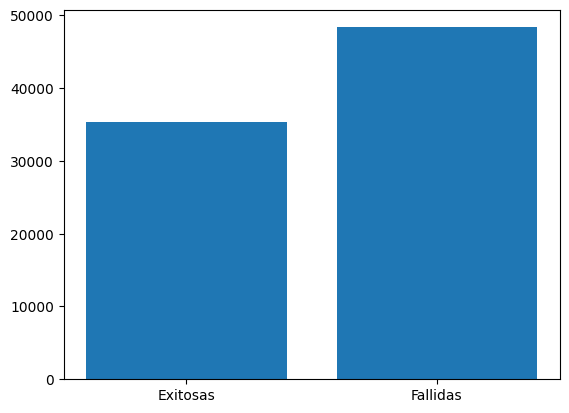

In [231]:
exitosas = df_final[df_final['msuccess'] == True]['msuccess'].count()
fallidas = df_final[df_final['msuccess'] == False]['msuccess'].count()
#print(exitosas, fallidas)
plt.bar(['Exitosas', 'Fallidas'], [exitosas, fallidas])
print(exitosas, fallidas, exitosas / (exitosas + fallidas) * 100, fallidas / (exitosas + fallidas) * 100)

Text(-12.430555555555555, 0.5, 'cantidad')

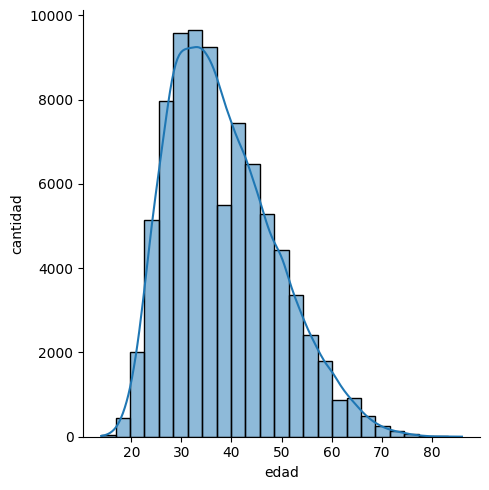

In [232]:
sns.displot(df_final['age'], kde=True, bins=25)
plt.xlabel('edad')
plt.ylabel('cantidad')

In [233]:
df_final['season'].unique()

['Spring', 'Autumn', 'Summer', 'Winter']
Categories (5, object): ['Autumn', 'Spring', 'Summer', 'Unknown', 'Winter']

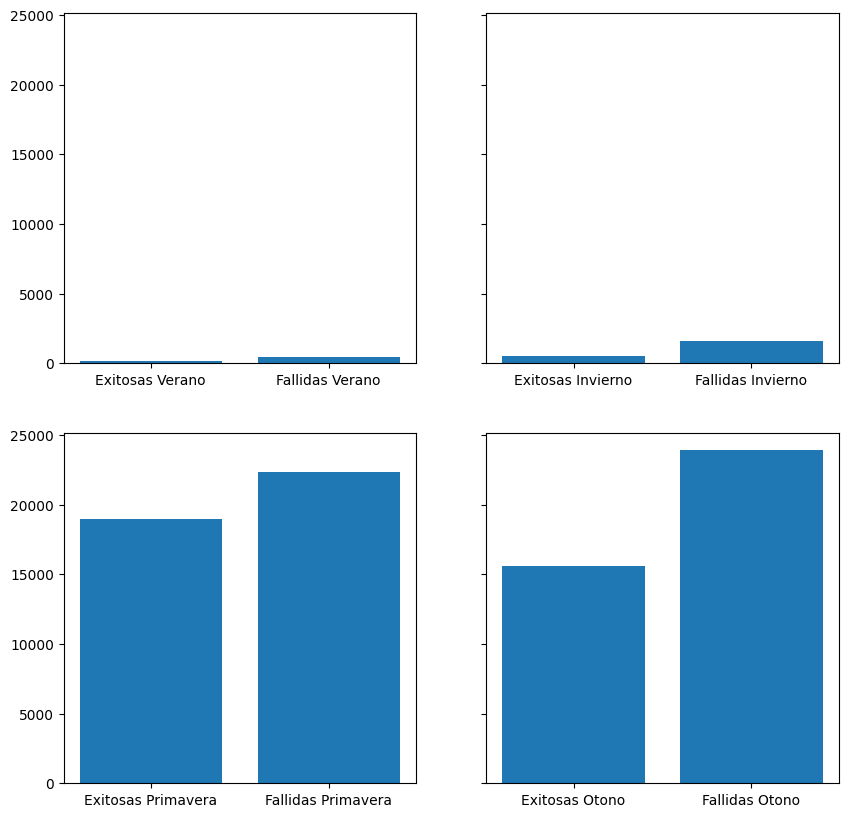

In [234]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10), sharey=True)
# El sharey normaliza todas las medidad a la misma, para poder compararlas con facilidad
ax[0, 0].bar(['Exitosas Verano', 'Fallidas Verano'], [len(df_final[(df_final['season'] == 'Summer') & (df_final['msuccess'] == True)]), len(df_final[(df_final['season'] == 'Summer') & (df_final['msuccess'] == False)])])
ax[0, 1].bar(['Exitosas Invierno', 'Fallidas Invierno'], [len(df_final[(df_final['season'] == 'Winter') & (df_final['msuccess'] == True)]), len(df_final[(df_final['season'] == 'Winter') & (df_final['msuccess'] == False)])])
ax[1, 0].bar(['Exitosas Primavera', 'Fallidas Primavera'], [len(df_final[(df_final['season'] == 'Spring') & (df_final['msuccess'] == True)]), len(df_final[(df_final['season'] == 'Spring') & (df_final['msuccess'] == False)])])
ax[1, 1].bar(['Exitosas Otono', 'Fallidas Otono'], [len(df_final[(df_final['season'] == 'Autumn') & (df_final['msuccess'] == True)]), len(df_final[(df_final['season'] == 'Autumn') & (df_final['msuccess'] == False)])])
plt.show()

In [235]:
# Calculamos los porcentajes

verano = len(df_final[(df_final['season'] == 'Summer') & (df_final['msuccess'] == True)]) / len(df_final[(df_final['season'] == 'Summer') & (df_final['msuccess'] == False)]) * 100
invierno = len(df_final[(df_final['season'] == 'Winter') & (df_final['msuccess'] == True)]) / len(df_final[(df_final['season'] == 'Winter') & (df_final['msuccess'] == False)]) * 100
primavera = len(df_final[(df_final['season'] == 'Spring') & (df_final['msuccess'] == True)]) / len(df_final[(df_final['season'] == 'Spring') & (df_final['msuccess'] == False)]) * 100
otono = len(df_final[(df_final['season'] == 'Autumn') & (df_final['msuccess'] == True)]) / len(df_final[(df_final['season'] == 'Autumn') & (df_final['msuccess'] == False)]) * 100

print(verano, invierno, primavera, otono)

37.52665245202559 30.048959608323134 85.1282281205165 65.23702031602708


Text(0, 0.5, 'cantidad')

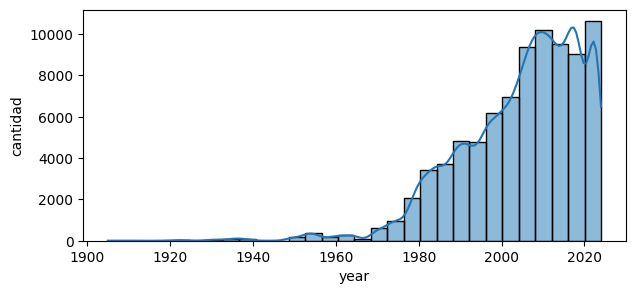

In [236]:
fig, ax = plt.subplots(1, 1, figsize=(7,3))
ax = sns.histplot(data=df_final, x='year', bins=30, kde=True)
ax.set_xlabel('year')
ax.set_ylabel('cantidad')


<Axes: xlabel='year', ylabel='Count'>

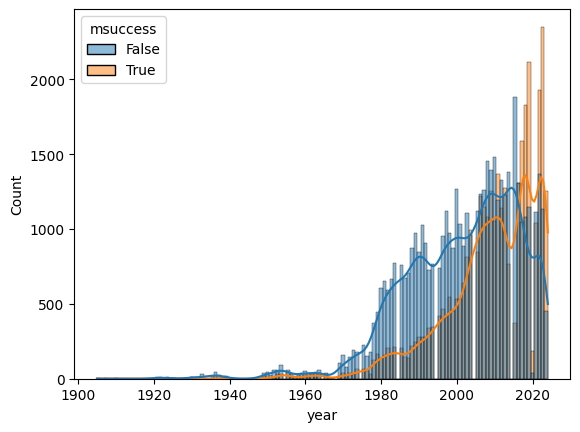

In [237]:
# Este tiene una bin por año, como se pidio, pero el siguiente tiene los bins de una forma que facilita la lectura del gráfico
sns.histplot(data=df_final, x='year', hue='msuccess', kde=True)

<Axes: xlabel='year', ylabel='Count'>

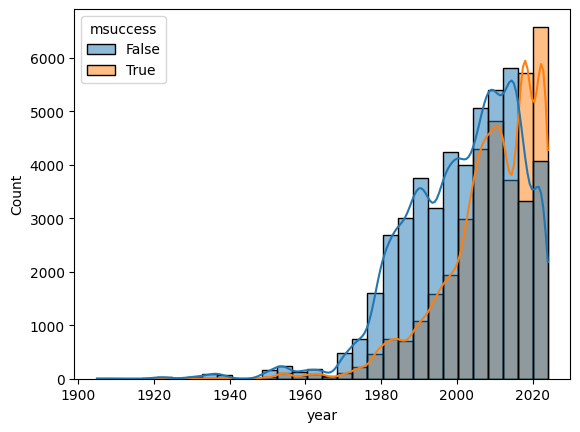

In [238]:
sns.histplot(data=df_final, x='year', hue='msuccess', kde=True, bins=30)

<Axes: >

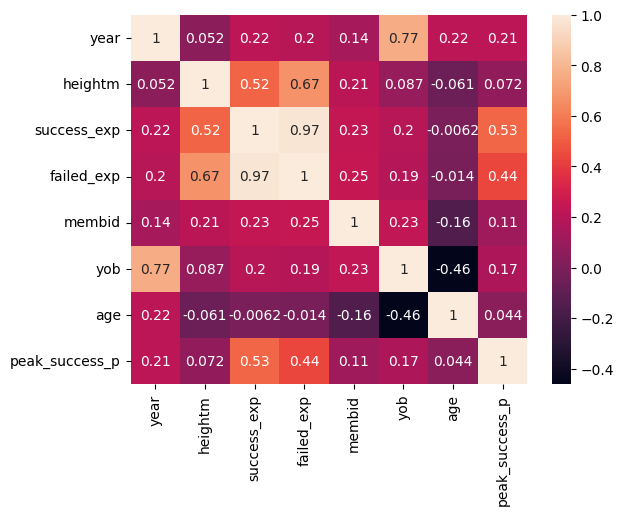

In [239]:
sns.heatmap(df_final.corr(numeric_only=True), annot=True)

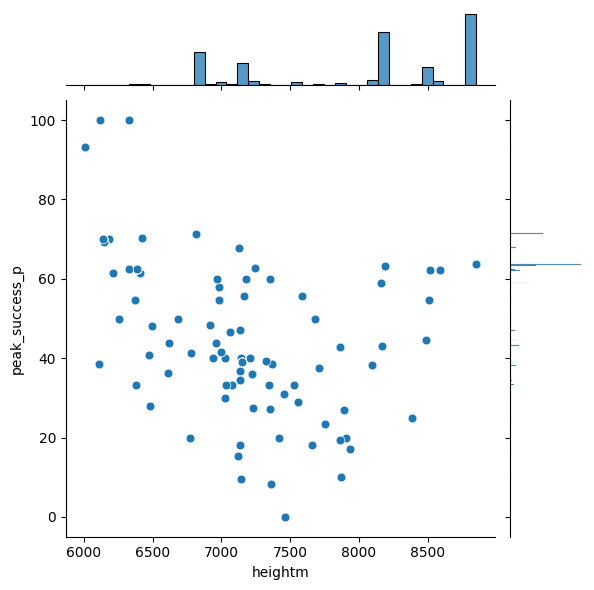

In [240]:
sns.jointplot(data=df_final[df_final['success_exp'] + df_final['failed_exp'] >= 10], y='peak_success_p', x='heightm', s=40, kind='scatter', edgecolor='w')

Respuestas:


a. **(0.5 pts)** ¿Cuántos ascensos exitosos y fallidos hay en su dataset? ¿A qué porcentaje del total corresponde cada categoría?

*  Hay 35260 ascensos exitosos y 48329 ascensos fallidos, que corresponden al 42.2% y 57.8% respectivamente de los ascensos totales. Esto se puede apreciar en el primer gráfico.

b. **(0.5 pts)** ¿Cómo se distribuyen las edades de los/las montañistas en la base de datos?

* Como se aprecia en el segundo gráfico, las edades abundan mas por diferencia entre los 25 y los 35 años.

c. **(0.5 pts)** ¿Cómo se distribuye la cantidad de ascensos según estación del año? ¿Cuál es el porcentaje de éxito por estación? Muestre la cantidad de filas de ascensos exitosas y fallidas para cada estación.

* Como se aprecia en el tercer gráfico, hay una gran diferencia con las intenciones en ascender en primavera u otoño, aunque como en el dataset hay montanas de los dos hemisferios, otono y primavera son practicamente la misma epoca del año, asi que se podria decir unicamente que evitan el calor y el frio extremo del verano e invierno. En verano hay un exito del 37.5% ; En invierno del 30% ; En primavera del 85.1% ; En otoño del 65.2%.

d. **(0.5 pts)** ¿Cómo cambia la cantidad de ascensos en el tiempo? Muestre la cantidad de ascensos exitosos y fallidos por año.

* Como se aprecia en el cuarto grafico, incrementa significativamente desde 1970 hasta 2010, desde ahi se mantiene en numeros similares. Como se aprecia en el quinto y sexto gráfico, se comenzo con una gran diferencia de los ascensos exitosos sobre los fallidos, pero con el paso de los años se van acercando hasta que los fallidos empiezan a superar a los exitosos alrededor del 2015.

e. **(0.5 pts)** ¿Existe una correlación entre el porcentaje de éxito de ascenso y la altura de una cumbre? Haga un scatterplot para todas las cumbres que hayan sido escaladas por al menos 10 expediciones en total (tanto fallidas como exitosas).

* Como se aprecia en el mapa de calor, hay una correlacion de 0.072, por ende no hay correlacion significativa, incluso como se aprecia en el ultimo gráfico, en el scatterplot estan todos los puntos dispersos, sin seguir una forma logica, por ende no hay correlacion alguna.

## 5. Predictor (2.5 puntos)

Ahora veremos si la información que tenemos nos permite predecir el éxito de un ascenso por alguna persona en particular. Primero, defina su **X** (matriz de atributos) e **y** (etiqueta a predecir) de la siguiente manera:

* **X**: `age`, `sex`, `citizen`, `season`, `heightm`, `year`, `success_exp`, `failed_exp`
* **y**: `msuccess`

Luego, realice los pasos a continuación:

**5.1 Codificación y normalización (1 pto)**
* Codifique todas las columnas categóricas, de manera que su matriz **X** solo tenga valores numéricos.
* Divida sus datos en sets de entrenamiento y testeo. Use una división de 70-30.
* Normalice sus matrices de atributos. Justifique su método de normalización.

**5.2 Creación y entrenamiento de modelos (1 pto)**
* Cree y entrene los siguientes modelos:
    * Un clasificador KNN
    * Un árbol de decisión
    * Un clasificador de regresión logística
    * Un clasificador random forest **(Opcional)**

    Explique qué hiperparámetros utilizó para la creación de cada uno de ellos y qué valores le asignó.

* Finalmente, evalúe todos sus modelos con el set de testeo. Para cada uno, muestre
    * Accuracy
    * Precisión
    * Recall
    * Matriz de confusión

**5.3 Análisis de resultados (0.5 pts)**

Interprete, analice y comente sus resultados. 
* ¿Qué tendencias puede observar? ¿Se diferencian de alguna forma las predicciones entre un modelo y otro? 
* ¿Fue posible construir un predictor efectivo? Justique.



In [241]:
df_predictor = df_final.copy()

In [242]:
df_predictor.head(1)

,expid,year,season,peakid,pkname,heightm,success_exp,failed_exp,membid,sex,yob,citizen,msuccess,age,peak_success_p
42348,EVER14152,2014.0,Spring,EVER,Everest,8849,1495,852,5,F,2000.0,India,True,14.0,63.698338


In [243]:
# respuestas
X = df_predictor[['age', 'sex', 'citizen', 'season', 'heightm', 'year', 'success_exp', 'failed_exp']]

# El y lo mapea para convertir los booleanos a numeeros, asi no da error en knn
Y = df_predictor['msuccess'].map(lambda x: {True: 1, False: 0}.get(x))
print(X, Y)

        age sex    citizen  season  heightm    year  success_exp  failed_exp
42348  14.0   F      India  Spring     8849  2014.0         1495         852
16616  14.0   M  Australia  Autumn     7152  2019.0          131         204
22202  14.0   F    Romania  Autumn     8188  2009.0          861         498
18568  14.0   M    S Korea  Spring     8188  2000.0          861         498
38658  14.0   M        USA  Spring     8849  2010.0         1495         852
...     ...  ..        ...     ...      ...     ...          ...         ...
29460  83.0   M      Spain  Spring     8167  2022.0          183         241
29543  84.0   M      Spain  Spring     8167  2023.0          183         241
88163  84.0   M      Japan  Autumn     6343  2018.0            1           8
43124  84.0   M      Nepal  Spring     8849  2015.0         1495         852
44816  86.0   M      Nepal  Spring     8849  2017.0         1495         852

[83589 rows x 8 columns] 42348    1
16616    0
22202    0
18568    0
38658 

In [244]:
df_predictor.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83589 entries, 42348 to 44816
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   expid           83589 non-null  object  
 1   year            83589 non-null  float64 
 2   season          83589 non-null  category
 3   peakid          83589 non-null  object  
 4   pkname          83589 non-null  object  
 5   heightm         83589 non-null  int64   
 6   success_exp     83589 non-null  int64   
 7   failed_exp      83589 non-null  int64   
 8   membid          83589 non-null  int64   
 9   sex             83589 non-null  category
 10  yob             83589 non-null  float64 
 11  citizen         83589 non-null  object  
 12  msuccess        83589 non-null  object  
 13  age             83589 non-null  float64 
 14  peak_success_p  83589 non-null  float64 
dtypes: category(2), float64(4), int64(4), object(5)
memory usage: 9.1+ MB


In [245]:
# con get_dummies obtenemos que los valores categoricos sean numericos con 0 y 1
X = pd.get_dummies(X, columns=['season', 'sex', 'citizen'], drop_first=True, dtype=int)
print(X)

        age  heightm    year  success_exp  failed_exp  season_Spring  \
42348  14.0     8849  2014.0         1495         852              1   
16616  14.0     7152  2019.0          131         204              0   
22202  14.0     8188  2009.0          861         498              0   
18568  14.0     8188  2000.0          861         498              1   
38658  14.0     8849  2010.0         1495         852              1   
...     ...      ...     ...          ...         ...            ...   
29460  83.0     8167  2022.0          183         241              1   
29543  84.0     8167  2023.0          183         241              1   
88163  84.0     6343  2018.0            1           8              0   
43124  84.0     8849  2015.0         1495         852              1   
44816  86.0     8849  2017.0         1495         852              1   

       season_Summer  season_Unknown  season_Winter  sex_M  ...  citizen_USSR  \
42348              0               0              0   

In [246]:
# normaliza los datos a una misma escala con la forma vista en clases, ya que lleva los datos a una escala razonable
sc = StandardScaler()
X_sc = sc.fit_transform(X)

In [247]:
# Divide los datos entre entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X_sc, Y, test_size = 0.3, random_state = 5)

In [248]:
# Entrena el modelo KNN con el hiperparametro k = 5
classifier = KNeighborsClassifier(n_neighbors = 5)
classifier.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [249]:
y_pred_test = classifier.predict(X_test)

Confusion matrix: [[11048  3301]
 [ 3981  6747]]
Accuracy: 0.7096143876859273
Recall: 0.6289149888143176
Precision: 0.6714769108280255
              precision    recall  f1-score   support

           0       0.74      0.77      0.75     14349
           1       0.67      0.63      0.65     10728

    accuracy                           0.71     25077
   macro avg       0.70      0.70      0.70     25077
weighted avg       0.71      0.71      0.71     25077



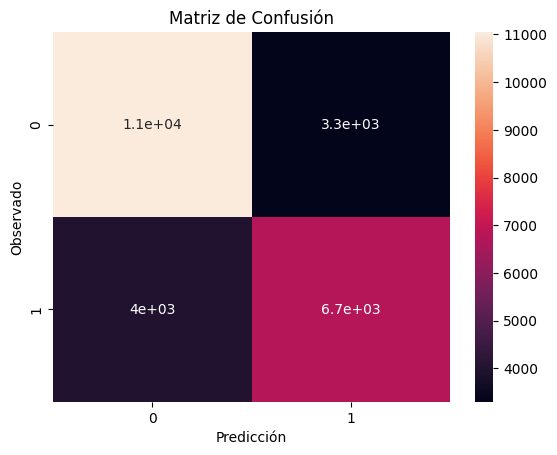

In [250]:

#matriz de confusión
cm = metrics.confusion_matrix(y_test, y_pred_test)

print('Confusion matrix:', cm)

#graficamos la matriz de confusión
sns.heatmap(cm, annot=True)
plt.ylabel('Observado')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión')

accuracy=metrics.accuracy_score(y_test,y_pred_test)
print('Accuracy:',accuracy) 

recall=metrics.recall_score(y_test,y_pred_test)
print('Recall:',recall) 

precision=metrics.precision_score(y_test,y_pred_test)
print('Precision:',precision) 

report0 = metrics.classification_report(y_test,y_pred_test)
print(report0)

In [251]:

#definimos el modelo y especificamos sus hiperparámetros (arbol de decision), con una profundidad de solo 4, ya que al ponerle mas, se volvia tan especifico que no se apreciaba con el ojo humano
classifier = DecisionTreeClassifier(max_depth=4)

#ajustamos a los datos de entrenamiento
classifier.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [252]:
# Testeamos
y_pred_test = classifier.predict(X_test)

[Text(0.5, 0.9, 'x[131] <= 0.674\ngini = 0.487\nsamples = 58512\nvalue = [33980, 24532]'),
 Text(0.25, 0.7, 'x[2] <= -0.216\ngini = 0.446\nsamples = 45701\nvalue = [30358, 15343]'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'x[1] <= -1.312\ngini = 0.362\nsamples = 19317\nvalue = [14726, 4591]'),
 Text(0.0625, 0.3, 'x[5] <= 0.012\ngini = 0.494\nsamples = 2733\nvalue = [1511, 1222]'),
 Text(0.03125, 0.1, 'gini = 0.5\nsamples = 1990\nvalue = [1013, 977]'),
 Text(0.09375, 0.1, 'gini = 0.442\nsamples = 743\nvalue = [498.0, 245.0]'),
 Text(0.1875, 0.3, 'x[248] <= 9.176\ngini = 0.324\nsamples = 16584\nvalue = [13215, 3369]'),
 Text(0.15625, 0.1, 'gini = 0.319\nsamples = 16414\nvalue = [13140, 3274]'),
 Text(0.21875, 0.1, 'gini = 0.493\nsamples = 170\nvalue = [75, 95]'),
 Text(0.375, 0.5, 'x[3] <= -0.591\ngini = 0.483\nsamples = 26384\nvalue = [15632, 10752]'),
 Text(0.3125, 0.3, 'x[4] <= -1.337\ngini = 0.408\nsamples = 9419\nvalue = [6728, 2691]'),
 Text(0.28125, 0.1, 'gini = 0.436\nsamp

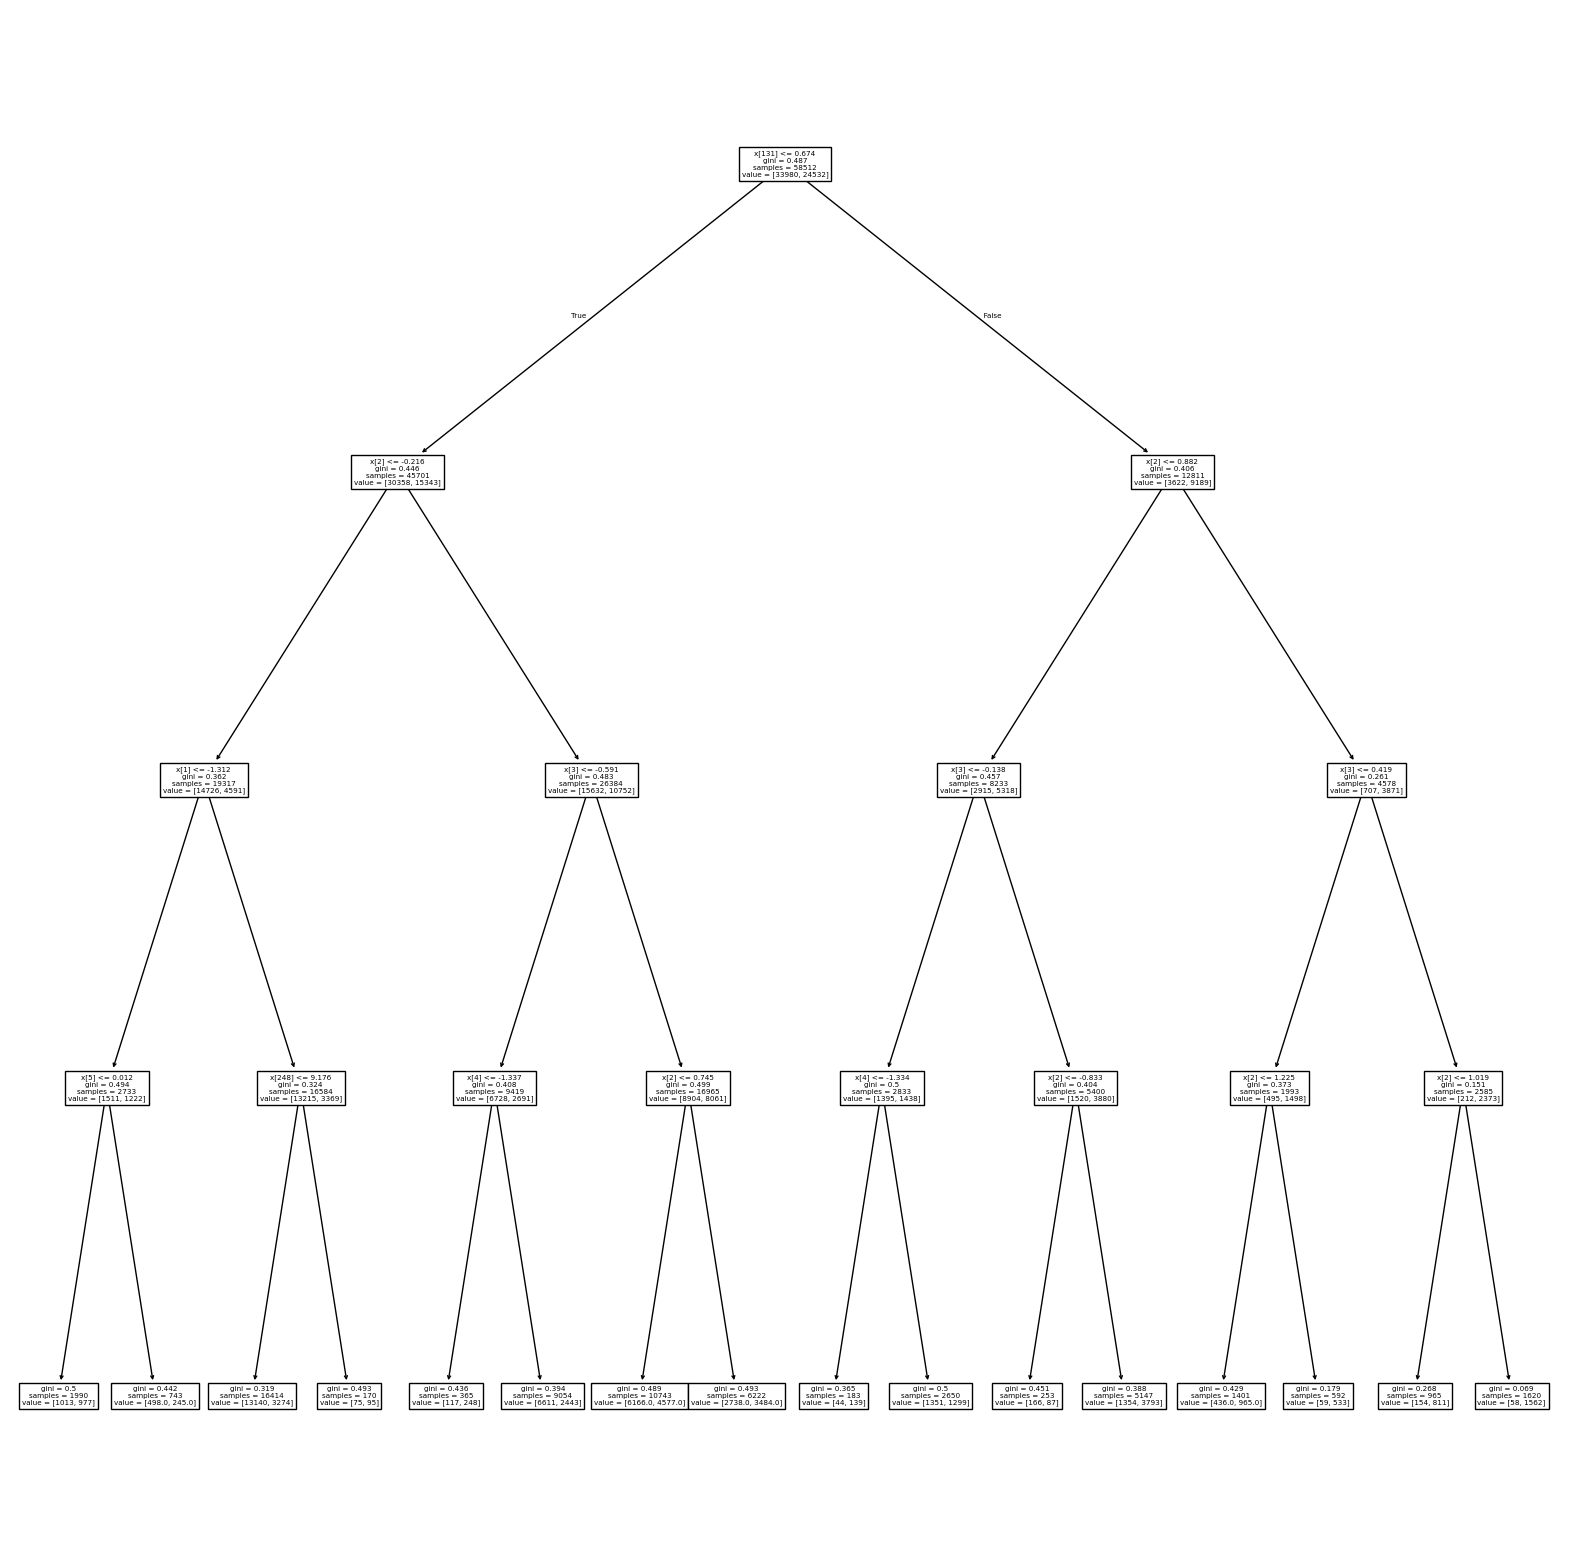

In [253]:
# grafica el arbol
fig = plt.figure(figsize=(20,20))
ax = fig.add_subplot(111)
plot_tree(classifier, ax=ax)

Confusion matrix: [[12190  2159]
 [ 5616  5112]]
Accuracy: 0.6899549387885313
Recall: 0.47651006711409394
Precision: 0.7030669784073718
              precision    recall  f1-score   support

           0       0.68      0.85      0.76     14349
           1       0.70      0.48      0.57     10728

    accuracy                           0.69     25077
   macro avg       0.69      0.66      0.66     25077
weighted avg       0.69      0.69      0.68     25077



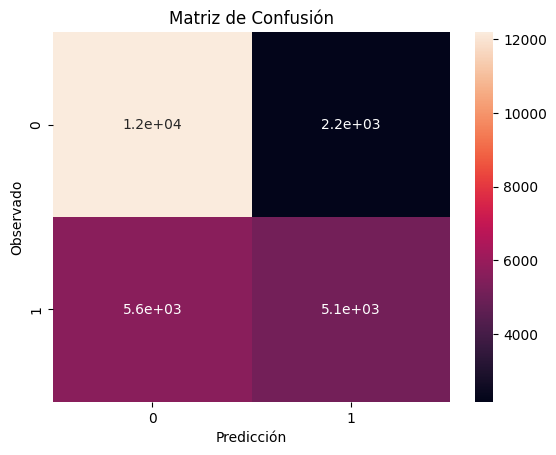

In [254]:
#matriz de confusión
cm = metrics.confusion_matrix(y_test, y_pred_test)


print('Confusion matrix:',cm)

#graficamos la matriz de confusión
sns.heatmap(cm,annot=True)
plt.ylabel('Observado')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión')

accuracy = metrics.accuracy_score(y_test,y_pred_test)
print('Accuracy:',accuracy)

recall = metrics.recall_score(y_test,y_pred_test)
print('Recall:',recall) 

precision = metrics.precision_score(y_test,y_pred_test)
print('Precision:',precision)


report0 = metrics.classification_report(y_test,y_pred_test)
print(report0)

In [255]:

# Agregamos el 1 al lado de la informacion, para poder hacer la regresion como se enseño en clases
X = sm.add_constant(X)
X

,const,age,heightm,year,success_exp,failed_exp,season_Spring,season_Summer,season_Unknown,season_Winter,...,citizen_USSR,citizen_Ukraine,citizen_Ukraine/Azerbaijan,citizen_Uruguay,citizen_Uzbekistan,citizen_Venezuela,citizen_Vietnam,citizen_W Germany,citizen_W Germany/Iran,citizen_Yugoslavia
42348,1.0,14.0,8849,2014.0,1495,852,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
16616,1.0,14.0,7152,2019.0,131,204,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
22202,1.0,14.0,8188,2009.0,861,498,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18568,1.0,14.0,8188,2000.0,861,498,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
38658,1.0,14.0,8849,2010.0,1495,852,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29460,1.0,83.0,8167,2022.0,183,241,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
29543,1.0,84.0,8167,2023.0,183,241,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
88163,1.0,84.0,6343,2018.0,1,8,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
43124,1.0,84.0,8849,2015.0,1495,852,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [256]:
# Entrenar el modelo
model = LogisticRegression()
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)

# Evaluar desempeño
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {acc:.3f}\nPrecision: {prec:.3f}\nRecall: {rec:.3f}")

Accuracy: 0.695
Precision: 0.682
Recall: 0.536


Text(0.5, 1.0, 'Matriz de Confusión')

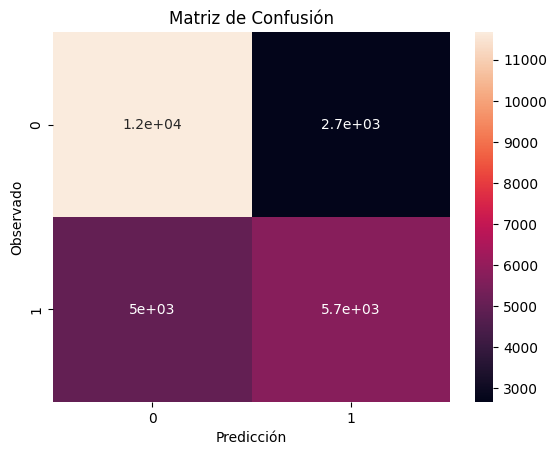

In [260]:
#matriz de confusión
cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(cm,annot=True)
plt.ylabel('Observado')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión')

Respuestas:

* ¿Qué tendencias puede observar? ¿Se diferencian de alguna forma las predicciones entre un modelo y otro? 

    *  Los tres modelos poseen una matriz de confusion muy similar, con practicamente los mismos verdaderos negativos, pero difieren mucho en las predicciones falsas.

* ¿Fue posible construir un predictor efectivo? Justique.

    * Si, especialmente usando una clasificacion KNN, ya que esta es la que tiene mejores numeros en accuracy, recall y presicion, comparado con los otros dos, y estos son numeros muy cercanos al 1 (dentro de lo razonable), por ende seria un predictor efectivo.